<a href="https://colab.research.google.com/github/HariganeshV/Brain-Tumor-Detection/blob/main/Brain_Tumor_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


DATASET MOUNT

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive

 1771563600643.jpg
 Augmented_Training.zip
'BEEE PRESENTATION E0524007.mp4'
'Beee presentation video.html'
 BinaryDataset
 BrainTumorDataset.zip
'Cell biology class test-1.pdf'
 Classroom
'Colab Notebooks'
'Document from Hariganesh.pdf'
'Experiment 5 Web technology '
'Hariganesh - DS test (1).pdf'
'Hariganesh - DS test.pdf'
'Hariganesh V.jpeg'
'HG C PROGRAM CA3 ASSIGNMENT.pdf'
'HG Maths 4 (Assignment 3).pdf'
 IMG-20240725-WA0012.jpg
 IMG-20240823-WA0002.jpg
'LibraryManagementReport(14) (1).pdf'
'LibraryManagementReport(14) (2).pdf'
'LibraryManagementReport(14).pdf'
'Market Research on Meesho.pptx'
'maths assignment.pdf'
'MED23CL202 Python Laboratory '
 models
'Offer Letter Acceptance.pdf'
'PCP Abstract.pdf'
 Screenshot_2024_0918_124219.jpg
'STUDENT PERSONAL DETAILS.docx'
 Testing
 Training
'Untitled spreadsheet (1).gsheet'
'Untitled spreadsheet.gsheet'
'VID-20241105-WA0000 (1).mp4'
'VID-20241105-WA0000 (2).mp4'
 VID-20241105-WA0000.mp4
'Web technology exp 4'
'WhatsApp Image 2025-06-17 

In [ ]:
!unzip "/content/drive/MyDrive/Augmented_Training.zip" -d "/content/drive/MyDrive/Augmented_Training"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/Augmented_Training/Augmented_Training/notumor/aug_0_1698.jpg  
  inflating: /content/drive/MyDrive/Augmented_Training/Augmented_Training/notumor/aug_0_1701.jpg  
  inflating: /content/drive/MyDrive/Augmented_Training/Augmented_Training/notumor/aug_0_1703.jpg  
  inflating: /content/drive/MyDrive/Augmented_Training/Augmented_Training/notumor/aug_0_1727.jpg  
  inflating: /content/drive/MyDrive/Augmented_Training/Augmented_Training/notumor/aug_0_1736.jpg  
  inflating: /content/drive/MyDrive/Augmented_Training/Augmented_Training/notumor/aug_0_1768.jpg  
  inflating: /content/drive/MyDrive/Augmented_Training/Augmented_Training/notumor/aug_0_1774.jpg  
  inflating: /content/drive/MyDrive/Augmented_Training/Augmented_Training/notumor/aug_0_1782.jpg  
  inflating: /content/drive/MyDrive/Augmented_Training/Augmented_Training/notumor/aug_0_1796.jpg  
  inflating: /content/drive/MyDrive/Augmented_Training/Aug

In [ ]:
!ls "/content/drive/MyDrive/Augmented_Training"

Augmented_Training


Check Class Folders

In [ ]:
!ls "/content/drive/MyDrive/Augmented_Training"

Augmented_Training


In [ ]:
!ls "/content/drive/MyDrive/Augmented_Training/Augmented_Training"

glioma	meningioma  notumor  pituitary


Load Training Generator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Augmented_Training/Augmented_Training",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Augmented_Training/Augmented_Training",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 8388 images belonging to 4 classes.
Found 2096 images belonging to 4 classes.


Build Transfer Learning Model (VGG16)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,500 (80.64 MB)

 Trainable params: 6,423,812 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Multi-Class Train Model (With EarlyStopping)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/models/multiclass_model.h5",   # save path
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9110 - loss: 0.2318

263/263 ━━━━━━━━━━━━━━━━━━━━ 67s 256ms/step - accuracy: 0.9110 - loss: 0.2318 - val_accuracy: 0.9313 - val_loss: 0.1900
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9238 - loss: 0.2168

263/263 ━━━━━━━━━━━━━━━━━━━━ 66s 250ms/step - accuracy: 0.9238 - loss: 0.2168 - val_accuracy: 0.9332 - val_loss: 0.1824
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9368 - loss: 0.1811

263/263 ━━━━━━━━━━━━━━━━━━━━ 66s 252ms/step - accuracy: 0.9368 - loss: 0.1811 - val_accuracy: 0.9356 - val_loss: 0.1713
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 66s 249ms/step - accuracy: 0.9426 - loss: 0.1677 - val_accuracy: 0.9098 - val_loss: 0.2282
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9454 - loss: 0.1503

263/263 ━━━━━━━━━━━━━━━━━━━━ 66s 250ms/step - accuracy: 0.9454 - loss: 0.1502 - val_accuracy: 0.9437 - val_loss: 0.1453
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9587 - loss: 0.1196

263/263 ━━━━━━━━━━━━━━━━━━━━ 66s 252ms/step - accuracy: 0.9587 - loss: 0.1196 - val_accuracy: 0.9594 - val_loss: 0.1199
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9577 - loss: 0.1164

263/263 ━━━━━━━━━━━━━━━━━━━━ 67s 251ms/step - accuracy: 0.9578 - loss: 0.1164 - val_accuracy: 0.9609 - val_loss: 0.1228
Epoch 8/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 67s 252ms/step - accuracy: 0.9696 - loss: 0.0937 - val_accuracy: 0.9556 - val_loss: 0.1213
Epoch 9/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 66s 250ms/step - accuracy: 0.9653 - loss: 0.0970 - val_accuracy: 0.9494 - val_loss: 0.1332
Epoch 10/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9734 - loss: 0.0747

263/263 ━━━━━━━━━━━━━━━━━━━━ 66s 250ms/step - accuracy: 0.9734 - loss: 0.0747 - val_accuracy: 0.9618 - val_loss: 0.1058
Epoch 11/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9774 - loss: 0.0722

263/263 ━━━━━━━━━━━━━━━━━━━━ 67s 252ms/step - accuracy: 0.9774 - loss: 0.0722 - val_accuracy: 0.9709 - val_loss: 0.0932
Epoch 12/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 66s 250ms/step - accuracy: 0.9811 - loss: 0.0620 - val_accuracy: 0.9633 - val_loss: 0.1003
Epoch 13/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 65s 248ms/step - accuracy: 0.9823 - loss: 0.0555 - val_accuracy: 0.9661 - val_loss: 0.1003
Epoch 14/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9866 - loss: 0.0520

263/263 ━━━━━━━━━━━━━━━━━━━━ 66s 251ms/step - accuracy: 0.9866 - loss: 0.0520 - val_accuracy: 0.9728 - val_loss: 0.0849
Epoch 15/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 66s 250ms/step - accuracy: 0.9899 - loss: 0.0416 - val_accuracy: 0.9475 - val_loss: 0.1346
Epoch 16/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 65s 248ms/step - accuracy: 0.9875 - loss: 0.0467 - val_accuracy: 0.9699 - val_loss: 0.0851
Epoch 17/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 73s 279ms/step - accuracy: 0.9900 - loss: 0.0393 - val_accuracy: 0.9709 - val_loss: 0.0865
Epoch 18/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 66s 250ms/step - accuracy: 0.9873 - loss: 0.0419 - val_accuracy: 0.9671 - val_loss: 0.0930
Epoch 19/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 65s 248ms/step - accuracy: 0.9848 - loss: 0.0433 - val_accuracy: 0.9690 - val_loss: 0.0886


In [ ]:
!ls /content/drive/MyDrive/models

multiclass_model.h5


In [ ]:
!ls /content/drive/MyDrive

 1771563600643.jpg
 Augmented_Training
 Augmented_Training.zip
'BEEE PRESENTATION E0524007.mp4'
'Beee presentation video.html'
 BrainTumorDataset.zip
'Cell biology class test-1.pdf'
 Classroom
'Colab Notebooks'
'Document from Hariganesh.pdf'
'Experiment 5 Web technology '
'Hariganesh - DS test (1).pdf'
'Hariganesh - DS test.pdf'
'Hariganesh V.jpeg'
'HG C PROGRAM CA3 ASSIGNMENT.pdf'
'HG Maths 4 (Assignment 3).pdf'
 IMG-20240725-WA0012.jpg
 IMG-20240823-WA0002.jpg
'LibraryManagementReport(14) (1).pdf'
'LibraryManagementReport(14) (2).pdf'
'LibraryManagementReport(14).pdf'
'Market Research on Meesho.pptx'
'maths assignment.pdf'
'MED23CL202 Python Laboratory '
 models
'Offer Letter Acceptance.pdf'
'PCP Abstract.pdf'
 Screenshot_2024_0918_124219.jpg
'STUDENT PERSONAL DETAILS.docx'
 Testing
'Untitled spreadsheet (1).gsheet'
'Untitled spreadsheet.gsheet'
'VID-20241105-WA0000 (1).mp4'
'VID-20241105-WA0000 (2).mp4'
 VID-20241105-WA0000.mp4
'Web technology exp 4'
'WhatsApp Image 2025-06-17 at 6.

Multiclass Model Testing

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/Testing",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

loss, acc = model.evaluate(test_generator)

print("Test Accuracy:", acc)

Found 1600 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 229ms/step - accuracy: 0.8148 - loss: 1.2541
Test Accuracy: 0.9037500023841858


Multi class CONFUSION MATRIX

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict on test data
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)

# Confusion Matrix
cm = confusion_matrix(test_generator.classes, y_pred)
print("Confusion Matrix:\n")
print(cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    test_generator.classes,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 250ms/step
Confusion Matrix:

[[287  74  30   9]
 [  7 367   6  20]
 [  0   1 397   2]
 [  0   5   0 395]]

Classification Report:

              precision    recall  f1-score   support

      glioma       0.98      0.72      0.83       400
  meningioma       0.82      0.92      0.87       400
     notumor       0.92      0.99      0.95       400
   pituitary       0.93      0.99      0.96       400

    accuracy                           0.90      1600
   macro avg       0.91      0.90      0.90      1600
weighted avg       0.91      0.90      0.90      1600



Confusion Matrix Graph

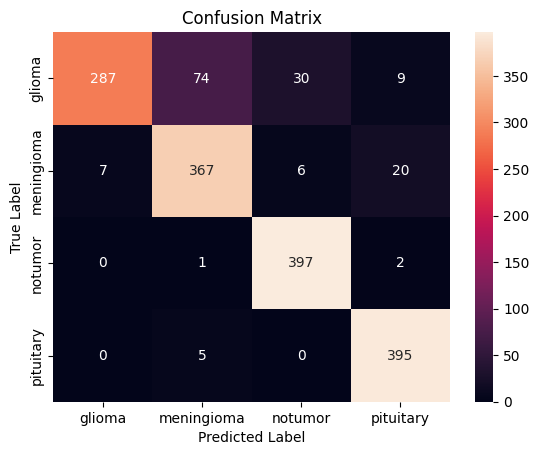

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix values (your result)
cm = np.array([
    [287, 74, 30, 9],
    [7, 367, 6, 20],
    [0, 1, 397, 2],
    [0, 5, 0, 395]
])

classes = ["glioma","meningioma","notumor","pituitary"]

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

#Grad-CAM Code for glioma IMAGE (Multi Class)

STEP 1 — Import libraries

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

STEP 2 — Initialize model graph

In [ ]:
dummy = np.zeros((1,224,224,3))
model.predict(dummy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


array([[1.9404051e-03, 1.7544128e-01, 8.2254404e-01, 7.4266303e-05]],
      dtype=float32)

STEP 3 — Select test image

In [ ]:
!ls "/content/drive/MyDrive/Testing/glioma"

Te-gl_100.jpg  Te-gl_173.jpg  Te-gl_245.jpg  Te-gl_317.jpg  Te-gl_38.jpg
Te-gl_101.jpg  Te-gl_174.jpg  Te-gl_246.jpg  Te-gl_318.jpg  Te-gl_390.jpg
Te-gl_102.jpg  Te-gl_175.jpg  Te-gl_247.jpg  Te-gl_319.jpg  Te-gl_391.jpg
Te-gl_103.jpg  Te-gl_176.jpg  Te-gl_248.jpg  Te-gl_31.jpg   Te-gl_392.jpg
Te-gl_104.jpg  Te-gl_177.jpg  Te-gl_249.jpg  Te-gl_320.jpg  Te-gl_393.jpg
Te-gl_105.jpg  Te-gl_178.jpg  Te-gl_24.jpg   Te-gl_321.jpg  Te-gl_394.jpg
Te-gl_106.jpg  Te-gl_179.jpg  Te-gl_250.jpg  Te-gl_322.jpg  Te-gl_395.jpg
Te-gl_107.jpg  Te-gl_17.jpg   Te-gl_251.jpg  Te-gl_323.jpg  Te-gl_396.jpg
Te-gl_108.jpg  Te-gl_180.jpg  Te-gl_252.jpg  Te-gl_324.jpg  Te-gl_397.jpg
Te-gl_109.jpg  Te-gl_181.jpg  Te-gl_253.jpg  Te-gl_325.jpg  Te-gl_398.jpg
Te-gl_10.jpg   Te-gl_182.jpg  Te-gl_254.jpg  Te-gl_326.jpg  Te-gl_399.jpg
Te-gl_110.jpg  Te-gl_183.jpg  Te-gl_255.jpg  Te-gl_327.jpg  Te-gl_39.jpg
Te-gl_111.jpg  Te-gl_184.jpg  Te-gl_256.jpg  Te-gl_328.jpg  Te-gl_3.jpg
Te-gl_112.jpg  Te-gl_185.jpg  Te-gl_257.jp

STEP 4 — Load image

In [ ]:
img_path = "/content/drive/MyDrive/Testing/glioma/Te-gl_100.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
from tensorflow.keras.models import load_model

functional_model = load_model("/content/drive/MyDrive/models/multiclass_model.h5")

In [ ]:
functional_model(np.zeros((1,224,224,3)))

<tf.Tensor: shape=(1, 4), dtype=float32, numpy=
array([[1.9404052e-03, 1.7544125e-01, 8.2254410e-01, 7.4266311e-05]],
      dtype=float32)>

Final Clean Working Method

In [ ]:
for layer in functional_model.layers:
    print(layer.name, type(layer))

vgg16 <class 'keras.src.models.functional.Functional'>
flatten <class 'keras.src.layers.reshaping.flatten.Flatten'>
dense <class 'keras.src.layers.core.dense.Dense'>
dropout <class 'keras.src.layers.regularization.dropout.Dropout'>
dense_1 <class 'keras.src.layers.core.dense.Dense'>


FINAL SIMPLE WORKING METHOD

STEP 1 — Get VGG Base Model

In [ ]:
base_model = functional_model.layers[0]   # this is vgg16
last_conv_layer = base_model.get_layer("block5_conv3")

STEP 2 — Create Grad Model Using Functional API Wrapper

In [ ]:
grad_model = Model(
    inputs=functional_model.layers[0].input,
    outputs=[
        last_conv_layer.output,
        functional_model.layers[-1].output
    ]
)

FINAL WORKING SOLUTION (Stable Method)

STEP 1 — Extract Base + Classifier Parts

In [ ]:
vgg = functional_model.layers[0]

classifier = tf.keras.Sequential(functional_model.layers[1:])

STEP 2 — Build Grad-CAM Model Properly

In [ ]:
grad_model = tf.keras.models.Model(
    inputs=vgg.input,
    outputs=[
        vgg.get_layer("block5_conv3").output,
        classifier(vgg.output)
    ]
)

STEP 3 — Generate Heatmap

In [ ]:
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    class_index = tf.argmax(predictions[0])
    loss = predictions[:, class_index]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]
heatmap = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)

heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
heatmap = heatmap.numpy()

FINAL STEP — Overlay Heatmap on MRI

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

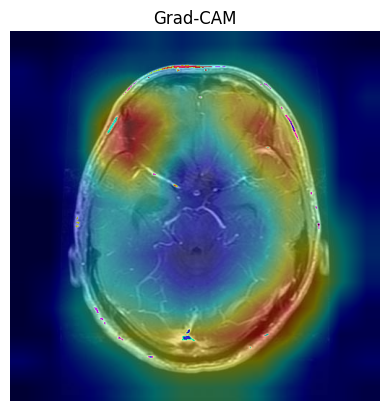

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Read original image
img = cv2.imread(img_path)

# Resize heatmap to image size
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap)

# Apply color map
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Overlay heatmap on image
superimposed_img = heatmap * 0.4 + img

# Show result
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM")
plt.axis("off")

In [ ]:
import numpy as np

# threshold for tumor activation
threshold = 0.6

# create mask
mask = heatmap > threshold

# count tumor pixels
tumor_pixels = np.sum(mask)

# count total pixels
total_pixels = heatmap.size

# percentage
tumor_percentage = (tumor_pixels / total_pixels) * 100

print("Tumor Area Percentage:", tumor_percentage)

Tumor Area Percentage: 65.58138529459634


In [ ]:
import numpy as np

# ---------- Ensure 2D heatmap ----------
if len(heatmap.shape) == 3:
    heatmap = heatmap[:, :, 0]

# ---------- NORMALIZE ----------
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

# ---------- ADAPTIVE THRESHOLD ----------
threshold = np.percentile(heatmap, 95)   # top 5% strongest activations

mask = heatmap >= threshold

# ---------- AREA CALCULATION ----------
tumor_pixels = np.sum(mask)
total_pixels = heatmap.size
tumor_percentage = (tumor_pixels / total_pixels) * 100

# ---------- SEVERITY ----------
if tumor_percentage < 5:
    severity = "Mild"
elif tumor_percentage < 15:
    severity = "Moderate"
elif tumor_percentage < 30:
    severity = "Serious"
else:
    severity = "Critical"

# ---------- LOCATION ----------
indices = np.where(mask)

if len(indices[0]) > 0:
    center_y = np.mean(indices[0])
    center_x = np.mean(indices[1])

    height, width = heatmap.shape

    if center_x < width * 0.4:
        location = "Left Hemisphere"
    elif center_x > width * 0.6:
        location = "Right Hemisphere"
    else:
        location = "Central Region"
else:
    location = "No strong activation"

# ---------- OUTPUT ----------
print("Tumor Area %:", round(tumor_percentage,2))
print("Severity:", severity)
print("Location:", location)

Tumor Area %: 36.04
Severity: Critical
Location: Central Region


#Grad-CAM for pituitary image (MULTI CLASS)

STEP 1 — Choose New Image

In [ ]:
!ls "/content/drive/MyDrive/Testing"

glioma	meningioma  notumor  pituitary


STEP 2 — List pituitary images

In [ ]:
!ls "/content/drive/MyDrive/Testing/pituitary"

Te-pi_100.jpg  Te-pi_173.jpg  Te-pi_245.jpg  Te-pi_317.jpg  Te-pi_38.jpg
Te-pi_101.jpg  Te-pi_174.jpg  Te-pi_246.jpg  Te-pi_318.jpg  Te-pi_390.jpg
Te-pi_102.jpg  Te-pi_175.jpg  Te-pi_247.jpg  Te-pi_319.jpg  Te-pi_391.jpg
Te-pi_103.jpg  Te-pi_176.jpg  Te-pi_248.jpg  Te-pi_31.jpg   Te-pi_392.jpg
Te-pi_104.jpg  Te-pi_177.jpg  Te-pi_249.jpg  Te-pi_320.jpg  Te-pi_393.jpg
Te-pi_105.jpg  Te-pi_178.jpg  Te-pi_24.jpg   Te-pi_321.jpg  Te-pi_394.jpg
Te-pi_106.jpg  Te-pi_179.jpg  Te-pi_250.jpg  Te-pi_322.jpg  Te-pi_395.jpg
Te-pi_107.jpg  Te-pi_17.jpg   Te-pi_251.jpg  Te-pi_323.jpg  Te-pi_396.jpg
Te-pi_108.jpg  Te-pi_180.jpg  Te-pi_252.jpg  Te-pi_324.jpg  Te-pi_397.jpg
Te-pi_109.jpg  Te-pi_181.jpg  Te-pi_253.jpg  Te-pi_325.jpg  Te-pi_398.jpg
Te-pi_10.jpg   Te-pi_182.jpg  Te-pi_254.jpg  Te-pi_326.jpg  Te-pi_399.jpg
Te-pi_110.jpg  Te-pi_183.jpg  Te-pi_255.jpg  Te-pi_327.jpg  Te-pi_39.jpg
Te-pi_111.jpg  Te-pi_184.jpg  Te-pi_256.jpg  Te-pi_328.jpg  Te-pi_3.jpg
Te-pi_112.jpg  Te-pi_185.jpg  Te-pi_257.jp

STEP 3 — Load that image

In [ ]:
img_path = "/content/drive/MyDrive/Testing/pituitary/Te-pi_100.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

STEP 4 — Generate heatmap

In [ ]:
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    class_index = tf.argmax(predictions[0])
    loss = predictions[:, class_index]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]
heatmap = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)

heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
heatmap = heatmap.numpy()

STEP 5 — Overlay heatmap

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

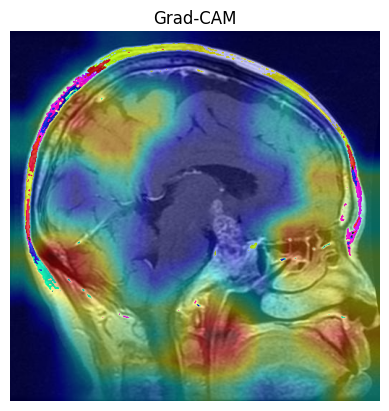

In [ ]:
img = cv2.imread(img_path)

heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)

heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
superimposed_img = heatmap_colored * 0.4 + img

plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM")
plt.axis("off")

STEP 1 — Automatic Severity Calculation

In [ ]:
import numpy as np

# ---- Severity Calculation ----
threshold = 0.6
mask = heatmap > threshold

tumor_pixels = np.sum(mask)
total_pixels = heatmap.size

tumor_percentage = (tumor_pixels / total_pixels) * 100

# Severity classification
if tumor_percentage < 5:
    severity = "Mild"
elif tumor_percentage < 15:
    severity = "Moderate"
elif tumor_percentage < 30:
    severity = "Serious"
else:
    severity = "Critical"

print("Tumor Area Percentage:", tumor_percentage)
print("Severity Level:", severity)

Tumor Area Percentage: 19.897959183673468
Severity Level: Serious


STEP 2 — Automatic Location Detection

In [ ]:
# ---- Location Detection ----
indices = np.where(mask)

if len(indices[0]) > 0:
    center_y = np.mean(indices[0])
    center_x = np.mean(indices[1])

    height, width = heatmap.shape

    if center_x < width * 0.4:
        location = "Left Hemisphere"
    elif center_x > width * 0.6:
        location = "Right Hemisphere"
    else:
        location = "Central Region"

else:
    location = "No significant activation detected"

print("Estimated Tumor Location:", location)

Estimated Tumor Location: Central Region


In [ ]:
import numpy as np

# ---------- SEVERITY ----------
threshold = 0.6
mask = heatmap > threshold

tumor_pixels = np.sum(mask)
total_pixels = heatmap.size
tumor_percentage = (tumor_pixels / total_pixels) * 100

# Severity scale
if tumor_percentage < 5:
    severity = "Mild"
elif tumor_percentage < 15:
    severity = "Moderate"
elif tumor_percentage < 30:
    severity = "Serious"
else:
    severity = "Critical"


# ---------- LOCATION ----------
indices = np.where(mask)

if len(indices[0]) > 0:
    center_y = np.mean(indices[0])
    center_x = np.mean(indices[1])

    height, width = heatmap.shape

    if center_x < width * 0.4:
        location = "Left Hemisphere"
    elif center_x > width * 0.6:
        location = "Right Hemisphere"
    else:
        location = "Central Region"
else:
    location = "No activation detected"


# ---------- RESULT ----------
print("Tumor Area %:", tumor_percentage)
print("Severity:", severity)
print("Location:", location)

Tumor Area %: 19.897959183673468
Severity: Serious
Location: Central Region



##Grad-CAM for meningioma image (MULTI CLASS)

STEP 1 — List meningioma images

In [ ]:
!ls "/content/drive/MyDrive/Testing/meningioma"

Te-aug-me_100.jpg  Te-aug-me_98.jpg  Te-me_189.jpg  Te-me_279.jpg
Te-aug-me_101.jpg  Te-aug-me_99.jpg  Te-me_18.jpg   Te-me_27.jpg
Te-aug-me_102.jpg  Te-aug-me_9.jpg   Te-me_190.jpg  Te-me_280.jpg
Te-aug-me_103.jpg  Te-me_100.jpg     Te-me_191.jpg  Te-me_281.jpg
Te-aug-me_10.jpg   Te-me_101.jpg     Te-me_192.jpg  Te-me_282.jpg
Te-aug-me_11.jpg   Te-me_102.jpg     Te-me_193.jpg  Te-me_283.jpg
Te-aug-me_12.jpg   Te-me_103.jpg     Te-me_194.jpg  Te-me_284.jpg
Te-aug-me_13.jpg   Te-me_104.jpg     Te-me_195.jpg  Te-me_285.jpg
Te-aug-me_14.jpg   Te-me_105.jpg     Te-me_196.jpg  Te-me_286.jpg
Te-aug-me_15.jpg   Te-me_106.jpg     Te-me_197.jpg  Te-me_287.jpg
Te-aug-me_16.jpg   Te-me_107.jpg     Te-me_198.jpg  Te-me_288.jpg
Te-aug-me_17.jpg   Te-me_108.jpg     Te-me_199.jpg  Te-me_289.jpg
Te-aug-me_18.jpg   Te-me_109.jpg     Te-me_19.jpg   Te-me_28.jpg
Te-aug-me_19.jpg   Te-me_10.jpg      Te-me_1.jpg    Te-me_290.jpg
Te-aug-me_1.jpg    Te-me_110.jpg     Te-me_200.jpg  Te-me_291.jpg
Te-aug-me_20

STEP 2 — Load that image

In [ ]:
img_path = "/content/drive/MyDrive/Testing/meningioma/Te-aug-me_100.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

STEP 3 — Generate Heatmap

In [ ]:
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    class_index = tf.argmax(predictions[0])
    loss = predictions[:, class_index]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]
heatmap = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)

heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
heatmap = heatmap.numpy()

STEP 4 — Overlay Heatmap

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

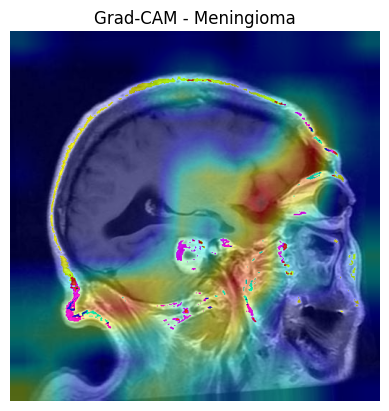

In [ ]:
img = cv2.imread(img_path)

heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)

heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
superimposed_img = heatmap_colored * 0.4 + img

plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM - Meningioma")
plt.axis("off")

SEVERITY AND LOCATION

In [ ]:
import numpy as np

# ---------- Ensure 2D ----------
if len(heatmap.shape) == 3:
    heatmap = heatmap[:, :, 0]

# ---------- Normalize ----------
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

# ---------- Adaptive Threshold (Top 5%) ----------
threshold = np.percentile(heatmap, 95)
mask = heatmap >= threshold

# ---------- Activation Percentage ----------
activated_pixels = np.sum(mask)
total_pixels = heatmap.size
activation_percentage = (activated_pixels / total_pixels) * 100

# ---------- Activation Severity (Attention Strength) ----------
if activation_percentage < 5:
    severity = "Low Activation"
elif activation_percentage < 15:
    severity = "Moderate Activation"
else:
    severity = "High Activation"

# ---------- Location Detection ----------
indices = np.where(mask)

if len(indices[0]) > 0:
    center_x = np.mean(indices[1])
    height, width = heatmap.shape

    left_ratio = np.sum(mask[:, :width//2]) / activated_pixels
    right_ratio = np.sum(mask[:, width//2:]) / activated_pixels

    if left_ratio > 0.65:
        location = "Left Hemisphere"
    elif right_ratio > 0.65:
        location = "Right Hemisphere"
    else:
        location = "Bilateral / Central Activation"
else:
    location = "No Strong Activation"

# ---------- Output ----------
print("Activation %:", round(activation_percentage,2))
print("Activation Severity:", severity)
print("Location:", location)

Activation %: 5.1
Activation Severity: Moderate Activation
Location: Right Hemisphere


#Grad-CAM for notumor image (MULTI CLASS)

STEP 1 — List notumor images

In [ ]:
!ls "/content/drive/MyDrive/Testing/notumor"

Te-no_100.jpg  Te-no_173.jpg  Te-no_245.jpg  Te-no_317.jpg  Te-no_38.jpg
Te-no_101.jpg  Te-no_174.jpg  Te-no_246.jpg  Te-no_318.jpg  Te-no_390.jpg
Te-no_102.jpg  Te-no_175.jpg  Te-no_247.jpg  Te-no_319.jpg  Te-no_391.jpg
Te-no_103.jpg  Te-no_176.jpg  Te-no_248.jpg  Te-no_31.jpg   Te-no_392.jpg
Te-no_104.jpg  Te-no_177.jpg  Te-no_249.jpg  Te-no_320.jpg  Te-no_393.jpg
Te-no_105.jpg  Te-no_178.jpg  Te-no_24.jpg   Te-no_321.jpg  Te-no_394.jpg
Te-no_106.jpg  Te-no_179.jpg  Te-no_250.jpg  Te-no_322.jpg  Te-no_395.jpg
Te-no_107.jpg  Te-no_17.jpg   Te-no_251.jpg  Te-no_323.jpg  Te-no_396.jpg
Te-no_108.jpg  Te-no_180.jpg  Te-no_252.jpg  Te-no_324.jpg  Te-no_397.jpg
Te-no_109.jpg  Te-no_181.jpg  Te-no_253.jpg  Te-no_325.jpg  Te-no_398.jpg
Te-no_10.jpg   Te-no_182.jpg  Te-no_254.jpg  Te-no_326.jpg  Te-no_399.jpg
Te-no_110.jpg  Te-no_183.jpg  Te-no_255.jpg  Te-no_327.jpg  Te-no_39.jpg
Te-no_111.jpg  Te-no_184.jpg  Te-no_256.jpg  Te-no_328.jpg  Te-no_3.jpg
Te-no_112.jpg  Te-no_185.jpg  Te-no_257.jp

STEP 2 — Load that image

In [ ]:
img_path = "/content/drive/MyDrive/Testing/notumor/Te-no_100.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

STEP 3 — Generate Heatmap

In [ ]:
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    class_index = tf.argmax(predictions[0])
    loss = predictions[:, class_index]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]
heatmap = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)

heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
heatmap = heatmap.numpy()

STEP 4 — Overlay Heatmap

(np.float64(-0.5), np.float64(441.5), np.float64(441.5), np.float64(-0.5))

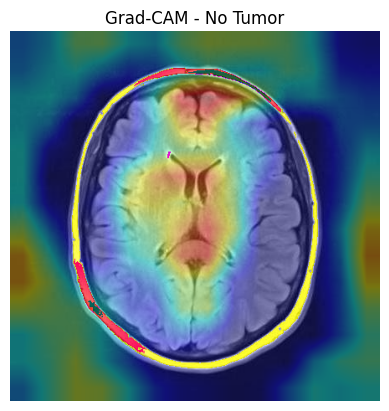

In [ ]:
img = cv2.imread(img_path)

heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)

heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
superimposed_img = heatmap_colored * 0.4 + img

plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM - No Tumor")
plt.axis("off")

#BINARY MODEL

STEP 1 —Create Binary Dataset Folders

In [ ]:
import os
import shutil

source = "/content/drive/MyDrive/Augmented_Training/Augmented_Training"
dest = "/content/drive/MyDrive/BinaryDataset"

classes = ["glioma","meningioma","pituitary","notumor"]

for c in classes:
    src = os.path.join(source,c)

    if c == "notumor":
        dst = os.path.join(dest,"notumor")
    else:
        dst = os.path.join(dest,"tumor")

    os.makedirs(dst, exist_ok=True)

    for file in os.listdir(src):
        shutil.copy(os.path.join(src,file), dst)

STEP 2 — Load Binary Dataset

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    "/content/drive/MyDrive/BinaryDataset",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    "/content/drive/MyDrive/BinaryDataset",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

Found 8013 images belonging to 2 classes.
Found 2002 images belonging to 2 classes.


STEP 3 — Build Binary Model

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model

base = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))

for layer in base.layers:
    layer.trainable = False

x = Flatten()(base.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

binary_model = Model(inputs=base.input, outputs=output)

binary_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

binary_model.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

STEP 4 — Train Model

In [ ]:
history = binary_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 86s 328ms/step - accuracy: 0.9003 - loss: 0.3972 - val_accuracy: 0.9835 - val_loss: 0.0451
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 248ms/step - accuracy: 0.9701 - loss: 0.0780 - val_accuracy: 0.9840 - val_loss: 0.0454
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 246ms/step - accuracy: 0.9765 - loss: 0.0573 - val_accuracy: 0.9785 - val_loss: 0.0766
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 61s 245ms/step - accuracy: 0.9823 - loss: 0.0571 - val_accuracy: 0.9895 - val_loss: 0.0330
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 61s 244ms/step - accuracy: 0.9832 - loss: 0.0503 - val_accuracy: 0.9650 - val_loss: 0.0826
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 245ms/step - accuracy: 0.9829 - loss: 0.0499 - val_accuracy: 0.9890 - val_loss: 0.0351
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 246ms/step - accuracy: 0.9867 - loss: 0.0423 - val_accuracy: 0.9905 - val_loss: 0.0238
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 62s 245ms/step - accuracy: 0.9879 - loss: 0

STEP 5 — Save Model

In [ ]:
binary_model.save("/content/drive/MyDrive/models/binary_model.h5")

METHOD 1 — Check Folder Structure

In [ ]:
!ls "/content/drive/MyDrive/BinaryDataset"

notumor  tumor


METHOD 2 — Check Inside Tumor Folder

In [ ]:
!ls "/content/drive/MyDrive/BinaryDataset/tumor" | head

aug_0_1001.jpg
aug_0_1004.jpg
aug_0_1006.jpg
aug_0_1011.jpg
aug_0_1017.jpg
aug_0_1018.jpg
aug_0_1020.jpg
aug_0_1022.jpg
aug_0_1028.jpg
aug_0_1036.jpg


METHOD 3 — Check Class Indices From Generator

In [ ]:
print(train_gen.class_indices)

{'notumor': 0, 'tumor': 1}


METHOD 4 — Count Images Per Class

In [ ]:
import os

base_path = "/content/drive/MyDrive/BinaryDataset"

for folder in os.listdir(base_path):
    print(folder, ":", len(os.listdir(os.path.join(base_path, folder))))

tumor : 7543
notumor : 2472


#BINARY MODEL ON TESTING DATASET

STEP 1 — Create Binary Testing Folder

In [ ]:
import os
import shutil

source = "/content/drive/MyDrive/Testing"
dest = "/content/drive/MyDrive/BinaryTesting"

classes = ["glioma","meningioma","pituitary","notumor"]

for c in classes:
    src = os.path.join(source,c)

    if c == "notumor":
        dst = os.path.join(dest,"notumor")
    else:
        dst = os.path.join(dest,"tumor")

    os.makedirs(dst, exist_ok=True)

    for file in os.listdir(src):
        shutil.copy(os.path.join(src,file), dst)

STEP 2 — Confirm Structure

In [ ]:
!ls "/content/drive/MyDrive/BinaryTesting"

notumor  tumor


STEP 3 — Load Binary Test Data

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/BinaryTesting",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 1600 images belonging to 2 classes.


STEP 4 — Evaluate Model

In [ ]:
loss, acc = binary_model.evaluate(test_gen)

print("Binary Test Accuracy:", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step - accuracy: 0.9731 - loss: 0.0896
Binary Test Accuracy: 0.9756249785423279


#Confusion Matrix for your Binary Model

STEP 1 — Make Sure You Use BinaryTesting Folder

In [ ]:
!ls "/content/drive/MyDrive/BinaryTesting"

notumor  tumor


STEP 2 — Load Binary Test Generator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/BinaryTesting",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 1600 images belonging to 2 classes.


STEP 3 — Get Predictions

In [ ]:
import numpy as np

pred = binary_model.predict(test_gen)
pred_classes = (pred > 0.5).astype(int).flatten()

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step


STEP 4 — Get True Labels

In [ ]:
true_classes = test_gen.classes

STEP 5 — Generate Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, pred_classes)

print("Confusion Matrix:")
print(cm)
print("Shape:", cm.shape)

Confusion Matrix:
[[ 392    8]
 [  31 1169]]
Shape: (2, 2)


STEP 7 — Graph

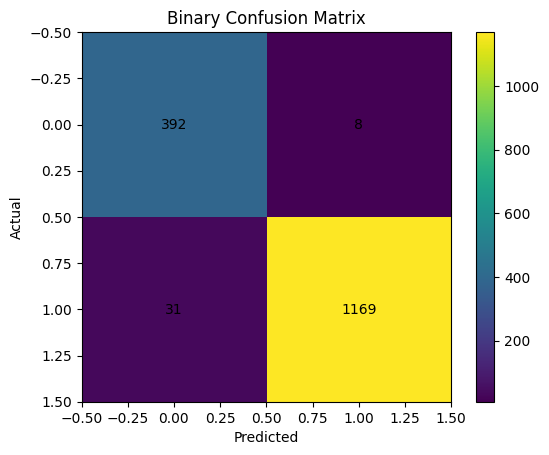

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Binary Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.show()

#Fine-Tuning (Multiclass)

Training dataset

STEP 1 — Load Saved Model

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/models/multiclass_model.h5")

STEP 2 — Unfreeze Last Convolution Block

In [ ]:
base_model = model.layers[0]

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-4:]:
    layer.trainable = True

STEP 3 — Recompile With LOW LR

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-5),   # VERY LOW LR
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

STEP 4 — Fine Tune Train

In [ ]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 82s 279ms/step - accuracy: 0.9849 - loss: 0.0483 - val_accuracy: 0.9427 - val_loss: 0.1556
Epoch 2/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 74s 280ms/step - accuracy: 0.9921 - loss: 0.0286 - val_accuracy: 0.9752 - val_loss: 0.0750
Epoch 3/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 81s 309ms/step - accuracy: 0.9955 - loss: 0.0193 - val_accuracy: 0.9771 - val_loss: 0.0753
Epoch 4/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 74s 281ms/step - accuracy: 0.9967 - loss: 0.0127 - val_accuracy: 0.9790 - val_loss: 0.0617
Epoch 5/5
263/263 ━━━━━━━━━━━━━━━━━━━━ 73s 279ms/step - accuracy: 0.9965 - loss: 0.0122 - val_accuracy: 0.9771 - val_loss: 0.0651


STEP 5 — Save Fine-Tuned Model

In [ ]:
model.save("/content/drive/MyDrive/models/multiclass_finetuned.h5")

Testing dataset

STEP 1 — Load Testing Generator (4 Classes)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "/content/drive/MyDrive/Testing",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 1600 images belonging to 4 classes.


STEP 2 — Evaluate Fine-Tuned Model

In [ ]:
loss, acc = model.evaluate(test_generator)

print("Fine-Tuned Test Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.8384 - loss: 1.5288
Fine-Tuned Test Accuracy: 0.9162499904632568


#Training Graphs

MULTICLASS FINE-TUNE GRAPHS

In [ ]:
from tensorflow.keras.models import load_model

STEP 1 — Reload Multiclass Model

In [ ]:
model = load_model("/content/drive/MyDrive/models/multiclass_finetuned.h5")

STEP 2 —Recreate Generators

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    "/content/drive/MyDrive/Augmented_Training/Augmented_Training",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    "/content/drive/MyDrive/Augmented_Training/Augmented_Training",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

Found 8388 images belonging to 4 classes.
Found 2096 images belonging to 4 classes.


STEP 3 — Short Training (for graphs only)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1,
    steps_per_epoch=20,
    validation_steps=5
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 554s 28s/step - accuracy: 0.9989 - loss: 0.0092 - val_accuracy: 0.9875 - val_loss: 0.0384


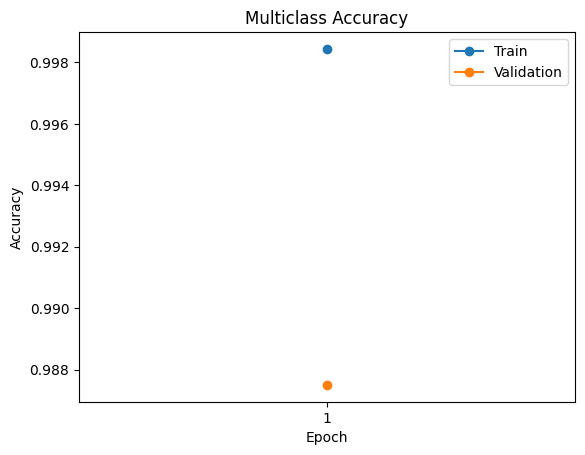

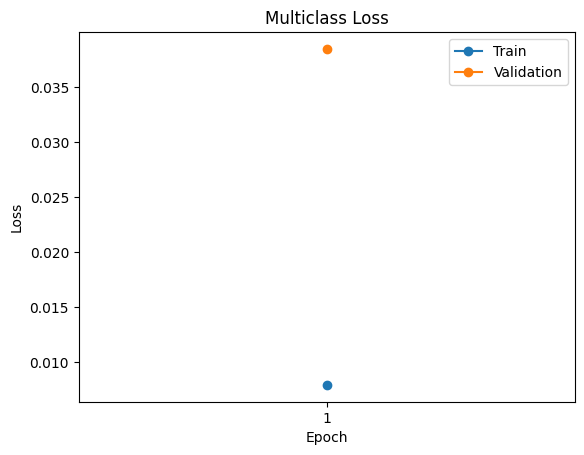

In [12]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(history_fine.history['accuracy']) + 1)

plt.figure()
plt.plot(epochs, history_fine.history['accuracy'], marker='o')
plt.plot(epochs, history_fine.history['val_accuracy'], marker='o')
plt.title("Multiclass Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.xticks(epochs)
plt.show()

plt.figure()
plt.plot(epochs, history_fine.history['loss'], marker='o')
plt.plot(epochs, history_fine.history['val_loss'], marker='o')
plt.title("Multiclass Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.xticks(epochs)
plt.show()

Binary model training graph

STEP 1 — Reload Binary Model

In [14]:
from tensorflow.keras.models import load_model

binary_model = load_model("/content/drive/MyDrive/models/binary_model.h5")

STEP 2 — Recreate Binary Generators

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator_binary = datagen.flow_from_directory(
    "/content/drive/MyDrive/BinaryDataset",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_generator_binary = datagen.flow_from_directory(
    "/content/drive/MyDrive/BinaryDataset",
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

Found 8013 images belonging to 2 classes.
Found 2002 images belonging to 2 classes.


Recompile Binary Model

In [17]:
from tensorflow.keras.optimizers import Adam

binary_model.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

STEP 3 — Short Training (FAST Graph Version)

In [19]:
history_binary = binary_model.fit(
    train_generator_binary,
    validation_data=val_generator_binary,
    epochs=2,
    steps_per_epoch=2,
    validation_steps=1
)

Epoch 1/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 90s 64s/step - accuracy: 1.0000 - loss: 8.6399e-04 - val_accuracy: 0.9688 - val_loss: 0.1513
Epoch 2/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 61s 44s/step - accuracy: 0.9792 - loss: 0.0330 - val_accuracy: 1.0000 - val_loss: 7.8691e-05


STEP 4 — Plot Graph

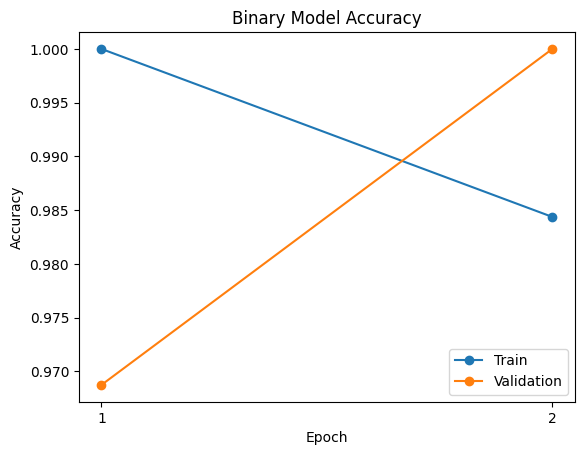

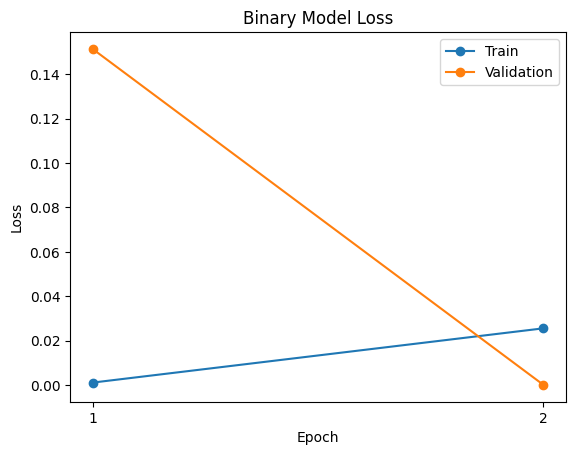

In [20]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(history_binary.history['accuracy']) + 1)

# Accuracy
plt.figure()
plt.plot(epochs, history_binary.history['accuracy'], marker='o')
plt.plot(epochs, history_binary.history['val_accuracy'], marker='o')
plt.title("Binary Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.xticks(epochs)
plt.show()

# Loss
plt.figure()
plt.plot(epochs, history_binary.history['loss'], marker='o')
plt.plot(epochs, history_binary.history['val_loss'], marker='o')
plt.title("Binary Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.xticks(epochs)
plt.show()

#FULL PIPELINE INTEGRATION

STEP 1 — Load Models

In [21]:
from tensorflow.keras.models import load_model

binary_model = load_model("/content/drive/MyDrive/models/binary_model.h5")
multiclass_model = load_model("/content/drive/MyDrive/models/multiclass_model.h5")

STEP 2 — Preprocess Function

In [22]:
import numpy as np
from tensorflow.keras.preprocessing import image

def preprocess(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

STEP 3 — Binary Prediction

In [23]:
def predict_binary(img_array):
    pred = binary_model.predict(img_array)
    return "Tumor" if pred[0][0] > 0.5 else "No Tumor"

STEP 4 — Multiclass Prediction

In [24]:
class_names = ["glioma","meningioma","notumor","pituitary"]

def predict_multiclass(img_array):
    pred = multiclass_model.predict(img_array)
    class_index = np.argmax(pred)
    return class_names[class_index]

STEP 5 — Final Integrated Function

In [25]:
def full_pipeline(img_path):

    img_array = preprocess(img_path)

    binary_result = predict_binary(img_array)

    if binary_result == "No Tumor":
        print("Result: No Tumor Detected")
        return

    print("Tumor Detected")

    tumor_type = predict_multiclass(img_array)
    print("Tumor Type:", tumor_type)

    # Grad-CAM call here (optional)
    # severity estimation call here

In [26]:
!ls "/content/drive/MyDrive/Testing/glioma"

Te-gl_100.jpg  Te-gl_173.jpg  Te-gl_245.jpg  Te-gl_317.jpg  Te-gl_38.jpg
Te-gl_101.jpg  Te-gl_174.jpg  Te-gl_246.jpg  Te-gl_318.jpg  Te-gl_390.jpg
Te-gl_102.jpg  Te-gl_175.jpg  Te-gl_247.jpg  Te-gl_319.jpg  Te-gl_391.jpg
Te-gl_103.jpg  Te-gl_176.jpg  Te-gl_248.jpg  Te-gl_31.jpg   Te-gl_392.jpg
Te-gl_104.jpg  Te-gl_177.jpg  Te-gl_249.jpg  Te-gl_320.jpg  Te-gl_393.jpg
Te-gl_105.jpg  Te-gl_178.jpg  Te-gl_24.jpg   Te-gl_321.jpg  Te-gl_394.jpg
Te-gl_106.jpg  Te-gl_179.jpg  Te-gl_250.jpg  Te-gl_322.jpg  Te-gl_395.jpg
Te-gl_107.jpg  Te-gl_17.jpg   Te-gl_251.jpg  Te-gl_323.jpg  Te-gl_396.jpg
Te-gl_108.jpg  Te-gl_180.jpg  Te-gl_252.jpg  Te-gl_324.jpg  Te-gl_397.jpg
Te-gl_109.jpg  Te-gl_181.jpg  Te-gl_253.jpg  Te-gl_325.jpg  Te-gl_398.jpg
Te-gl_10.jpg   Te-gl_182.jpg  Te-gl_254.jpg  Te-gl_326.jpg  Te-gl_399.jpg
Te-gl_110.jpg  Te-gl_183.jpg  Te-gl_255.jpg  Te-gl_327.jpg  Te-gl_39.jpg
Te-gl_111.jpg  Te-gl_184.jpg  Te-gl_256.jpg  Te-gl_328.jpg  Te-gl_3.jpg
Te-gl_112.jpg  Te-gl_185.jpg  Te-gl_257.jp

In [27]:
full_pipeline("/content/drive/MyDrive/Testing/glioma/Te-gl_100.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Tumor Detected
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 879ms/step
Tumor Type: glioma


#FINAL INTEGRATED PIPELINE (COMPLETE VERSION)

FINAL INTEGRATED PIPELINE (COMPLETE VERSION)

In [28]:
from tensorflow.keras.models import load_model

binary_model = load_model("/content/drive/MyDrive/models/binary_model.h5", compile=False)
multiclass_model = load_model("/content/drive/MyDrive/models/multiclass_model.h5", compile=False)

STEP 2 — Preprocess Function

In [29]:
import numpy as np
from tensorflow.keras.preprocessing import image

def preprocess(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

STEP 3 — Binary Prediction

In [30]:
def predict_binary(img_array):
    pred = binary_model.predict(img_array)
    confidence = float(pred[0][0])
    label = "Tumor" if confidence > 0.5 else "No Tumor"
    return label, confidence

STEP 4 — Multiclass Prediction

In [31]:
class_names = ["glioma","meningioma","notumor","pituitary"]

def predict_multiclass(img_array):
    pred = multiclass_model.predict(img_array)
    class_index = np.argmax(pred)
    confidence = float(pred[0][class_index])
    return class_names[class_index], confidence

STEP 5 — Severity Estimation

In [32]:
def estimate_severity(heatmap):
    threshold = 0.6
    mask = heatmap > threshold
    tumor_percentage = (np.sum(mask) / heatmap.size) * 100

    if tumor_percentage < 5:
        level = "Mild"
    elif tumor_percentage < 15:
        level = "Moderate"
    elif tumor_percentage < 30:
        level = "Serious"
    else:
        level = "Critical"

    return tumor_percentage, level

STEP 6 — Location Detection

In [33]:
def detect_location(heatmap):
    threshold = 0.6
    mask = heatmap > threshold

    if np.sum(mask) == 0:
        return "No Significant Activation"

    indices = np.where(mask)
    center_x = np.mean(indices[1])
    width = heatmap.shape[1]

    if center_x < width * 0.4:
        return "Left Hemisphere"
    elif center_x > width * 0.6:
        return "Right Hemisphere"
    else:
        return "Central Region"

STEP 7 — FULL PROFESSIONAL PIPELINE

In [34]:
def full_pipeline(img_path):

    img_array = preprocess(img_path)

    # ---- Binary ----
    binary_label, binary_conf = predict_binary(img_array)

    if binary_label == "No Tumor":
        print("🧠 Diagnosis Result")
        print("----------------------------")
        print("Result: No Tumor Detected")
        print(f"Confidence: {round((1-binary_conf)*100,2)}%")
        return

    # ---- Multiclass ----
    tumor_type, multi_conf = predict_multiclass(img_array)

    # ---- Grad-CAM ----
    heatmap = make_gradcam_heatmap(img_array, multiclass_model)  # you already built this

    location = detect_location(heatmap)
    tumor_area, severity = estimate_severity(heatmap)

    # ---- Final Output ----
    print("🧠 Diagnosis Result")
    print("----------------------------")
    print("Tumor Detected")
    print(f"Tumor Type: {tumor_type}")
    print(f"Confidence: {round(multi_conf*100,2)}%")
    print(f"Location: {location}")
    print(f"Tumor Area: {round(tumor_area,2)}%")
    print(f"Severity Level: {severity}")

In [35]:
!ls "/content/drive/MyDrive/Testing/glioma"

Te-gl_100.jpg  Te-gl_173.jpg  Te-gl_245.jpg  Te-gl_317.jpg  Te-gl_38.jpg
Te-gl_101.jpg  Te-gl_174.jpg  Te-gl_246.jpg  Te-gl_318.jpg  Te-gl_390.jpg
Te-gl_102.jpg  Te-gl_175.jpg  Te-gl_247.jpg  Te-gl_319.jpg  Te-gl_391.jpg
Te-gl_103.jpg  Te-gl_176.jpg  Te-gl_248.jpg  Te-gl_31.jpg   Te-gl_392.jpg
Te-gl_104.jpg  Te-gl_177.jpg  Te-gl_249.jpg  Te-gl_320.jpg  Te-gl_393.jpg
Te-gl_105.jpg  Te-gl_178.jpg  Te-gl_24.jpg   Te-gl_321.jpg  Te-gl_394.jpg
Te-gl_106.jpg  Te-gl_179.jpg  Te-gl_250.jpg  Te-gl_322.jpg  Te-gl_395.jpg
Te-gl_107.jpg  Te-gl_17.jpg   Te-gl_251.jpg  Te-gl_323.jpg  Te-gl_396.jpg
Te-gl_108.jpg  Te-gl_180.jpg  Te-gl_252.jpg  Te-gl_324.jpg  Te-gl_397.jpg
Te-gl_109.jpg  Te-gl_181.jpg  Te-gl_253.jpg  Te-gl_325.jpg  Te-gl_398.jpg
Te-gl_10.jpg   Te-gl_182.jpg  Te-gl_254.jpg  Te-gl_326.jpg  Te-gl_399.jpg
Te-gl_110.jpg  Te-gl_183.jpg  Te-gl_255.jpg  Te-gl_327.jpg  Te-gl_39.jpg
Te-gl_111.jpg  Te-gl_184.jpg  Te-gl_256.jpg  Te-gl_328.jpg  Te-gl_3.jpg
Te-gl_112.jpg  Te-gl_185.jpg  Te-gl_257.jp

STEP 1 — Rebuild Clean Functional Model From Saved Model

In [41]:
from tensorflow.keras.models import load_model, Model

# Load sequential model
seq_model = load_model("/content/drive/MyDrive/models/multiclass_model.h5", compile=False)

# Extract layers
base_model = seq_model.layers[0]   # VGG16
flatten = seq_model.layers[1]
dense1 = seq_model.layers[2]
dropout = seq_model.layers[3]
output_layer = seq_model.layers[4]

# Rebuild clean functional model
x = base_model.output
x = flatten(x)
x = dense1(x)
x = dropout(x)
output = output_layer(x)

multiclass_model = Model(inputs=base_model.input, outputs=output)

STEP 2 — Clean Grad-CAM Function

In [42]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array, model):

    last_conv_layer = model.get_layer("block5_conv3")

    grad_model = Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()

STEP 3 — Call Pipeline

In [43]:
full_pipeline("/content/drive/MyDrive/Testing/glioma/Te-gl_100.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 880ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


🧠 Diagnosis Result
----------------------------
Tumor Detected
Tumor Type: glioma
Confidence: 100.0%
Location: Central Region
Tumor Area: 14.8%
Severity Level: Moderate
